In [54]:
# Importing requird Python modules
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

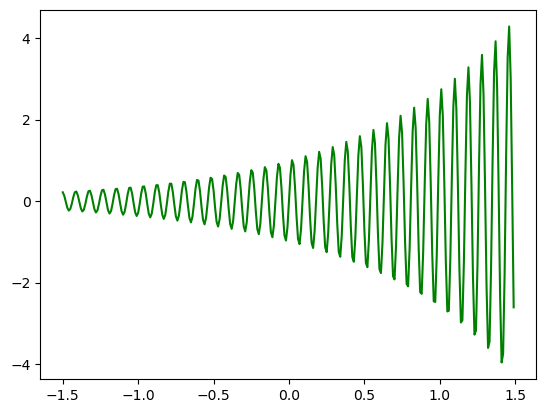

In [55]:
# Increase step-size to avoid undersampling
x = torch.arange(-1.5, 1.5, 0.01).view(-1, 1).type(torch.float32)
y = torch.sin(x*70)*torch.exp(x)
plt.plot(x, y, 'g')
plt.show()

In [56]:
class MultiLayerPerceptron(torch.nn.Module):
    def __init__(self, num_layers, hidden_size):
        super(MultiLayerPerceptron, self).__init__()
        self.hidden_layer_1st = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.ReLU(),
        )
        self.hidden_layers = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(hidden_size, hidden_size),
                    nn.Tanh() # Change activation function to tanh 
                ) for _ in range(num_layers - 1)
            ]
        )
        self.output_layer = nn.Linear(hidden_size, 1)

    # mathod called once the model is executed
    def forward(self, x):
        x = self.hidden_layer_1st(x)
        for layer in self.hidden_layers:
            x = layer(x)
        x = self.output_layer(x)
        return x # Linear activation at the end (so output is not constrained to -1/1)

In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiLayerPerceptron(num_layers=4, hidden_size=40).to(device)

# Better optimizer with smaller step
optimizer = optim.Adam(model.parameters(), lr=0.001)
MSE = nn.MSELoss()

# train
N_epochs = 100000
train_loss = []
model.train()
for _ in range(N_epochs):
    # this will zero out the gradients for this batch
    optimizer.zero_grad()
    # make predictions
    y_pred = model(x)
    # calculate the MSE loss
    loss = MSE(y_pred, y)
    # backpropagate the loss
    loss.backward()
    # update the model weights (with assumed learning rate)
    optimizer.step()
    train_loss.append(loss.item())

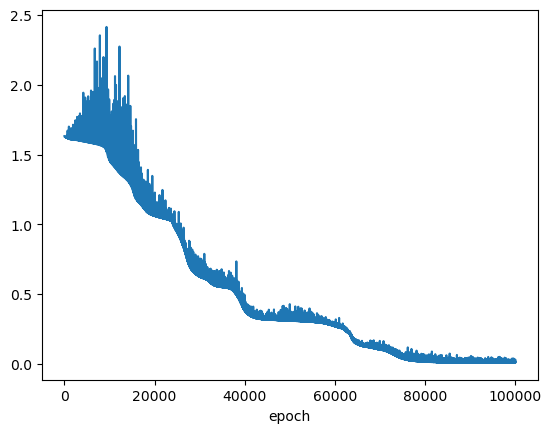

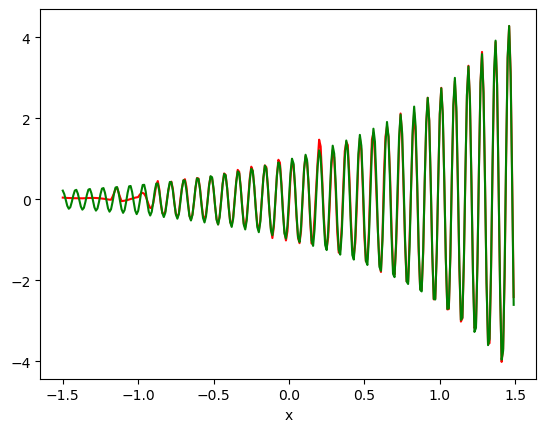

In [64]:
plt.plot(train_loss)
plt.xlabel('epoch')
plt.show()

model.eval()
plt.plot(x.cpu(), model(x).cpu().detach(), 'r')
plt.plot(x.cpu(), y.cpu(), 'g')
plt.xlabel('x')
plt.show()